In [1]:
import os
import psutil

pid = os.getpid()
print("PID:", pid)

p = psutil.Process(pid)
print("Name:", p.name())
print("Status:", p.status())
print("Memory:", p.memory_full_info())

PID: 41173
Name: python3.12
Status: running
Memory: pfullmem(rss=72876032, vms=445997989888, pfaults=8632, pageins=2, uss=59146240)


# Set Configuration

In [2]:
from diffusion_hash_inv.config import MainConfig, HashConfig, MessageConfig, OutputConfig, Byte2RGBConfig
from diffusion_hash_inv.main import MainEP
from diffusion_hash_inv.utils import FileIO
from diffusion_hash_inv.main import RuntimeConfig

length = 256
iteration = 2_000
RUN = True

main_cfg = MainConfig(
    verbose_flag=False,
    clean_flag=True,
    debug_flag=False,
    make_image_flag=True,
)
hash_cfg = HashConfig(
    hash_alg="md5",
    length=length,
)
message_cfg = MessageConfig(
    message_flag=False,
    length=length,
    random_flag=True,
    seed_flag=True,
)
output_cfg = OutputConfig()
byte2rgb_cfg = Byte2RGBConfig()
runtime_cfg = RuntimeConfig(
    main=main_cfg,
    message=message_cfg,
    hash=hash_cfg,
    output=output_cfg,
    rgb=byte2rgb_cfg,
)

io_controller = FileIO(main_config=main_cfg, output_cfg=output_cfg)

Clearing generated files...



In [3]:
if RUN:
    main = MainEP(runtime_config=runtime_cfg, file_controller=io_controller)
    main.run(iteration=iteration)

Main Entry Point Initialized.
Program Start Time: 2026-05-09 03:33:43.361177+09:00
Hash Algorithm: MD5
Message Length: 256
Data Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data
Output Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output


Hash Generation Progress: 100%|██████████| 2000/2000 [00:01<00:00, 1134.68iteration/s, Hash Algorithm=MD5, Message Length=256]


Hash Calculation time: 1 s, 777 ms, 58 us, 84 ns
Process completed.

RGB Image Maker Module Loaded.
RGB Image Maker Initialized.
Found 2000 logs to process.
Expected 142000 images to write (71 images per log).


Processing Logs: 100%|██████████| 2000/2000 [01:58<00:00, 16.91log/s, images=142000]

Image writing completed: 142000 images.
RGB Image Maker execution time: 118 s, 294 ms, 460 us, 42 ns
RGB Image Maker process completed.

Total Execution Time: 120 s, 71 ms, 518 us, 126 ns



In [4]:
from diffusion_hash_inv.logger.logger import Logs

logs = Logs.get_logs(io_controller, hash_cfg, main_cfg)
print(len(logs))
print(logs[0])

2000
{'MD5_256_2026-05-09 03-33-43_0000': {'Hash Algorithm': 'MD5', 'Byte order': 'little', 'Hierarchy': ['Step', 'Round', 'Loop'], 'Length': 256, 'Message': '0x5023a02b7da7cf3c584814613ca114ea9d74bc683782d15ae07b5832ec4d68b4', 'Logs': {'1st Step': '0x5023a02b7da7cf3c584814613ca114ea9d74bc683782d15ae07b5832ec4d68b4800000000000000000000000000000000000000000000000', '2nd Step': {'1st Block': ['0x5023a02b', '0x7da7cf3c', '0x58481461', '0x3ca114ea', '0x9d74bc68', '0x3782d15a', '0xe07b5832', '0xec4d68b4', '0x80000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00010000', '0x00000000']}, '3rd Step': {'A': '0x01234567', 'B': '0x89abcdef', 'C': '0xfedcba98', 'D': '0x76543210'}, '4th Step': {'1st Round': {'Loop Start': {'A': '0x01234567', 'B': '0x89abcdef', 'C': '0xfedcba98', 'D': '0x76543210'}, '1st Loop': {'A': '0x76543210', 'B': '0x0a8f3175', 'C': '0x89abcdef', 'D': '0xfedcba98'}, '2nd Loop': {'A': '0xfedcba98', 'B': '0x3fe125ce', 'C': '0x0a8f3175', 'D': '0x89a

In [5]:
def get_step4(logs):
    """
    Extract the "4th Step" logs from the given list of log dictionaries.
    """
    _step4_logs = []
    for _log in logs:
        _tmp = list(_log.values())
        assert len(_tmp) == 1, "Each log dictionary should contain exactly one key-value pair."
        log_dict = list(_log.values())[0]
        if "Logs" in log_dict and "4th Step" in log_dict["Logs"]:
            _step4_logs.append(log_dict["Logs"]["4th Step"])
    return _step4_logs

# Beta Scheduling
## Approach 1
**method**  
1. Cumulative all bytes from Hash algorithm calculation logs  
2. Make new Beta Schedule by multiply Base Beta Schedule and Cumulative block


In [6]:
from typing import List, Dict, Any

step4_logs: List[Dict[str, Any]] = get_step4(logs)
assert len(step4_logs) == len(logs), f"Step 4 logs mismatch: {len(step4_logs)} != {len(logs)}"
print(step4_logs[0])
sn = list()

{'1st Round': {'Loop Start': {'A': '0x01234567', 'B': '0x89abcdef', 'C': '0xfedcba98', 'D': '0x76543210'}, '1st Loop': {'A': '0x76543210', 'B': '0x0a8f3175', 'C': '0x89abcdef', 'D': '0xfedcba98'}, '2nd Loop': {'A': '0xfedcba98', 'B': '0x3fe125ce', 'C': '0x0a8f3175', 'D': '0x89abcdef'}, '3rd Loop': {'A': '0x89abcdef', 'B': '0xf1e89c11', 'C': '0x3fe125ce', 'D': '0x0a8f3175'}, '4th Loop': {'A': '0x0a8f3175', 'B': '0x71da5ccd', 'C': '0xf1e89c11', 'D': '0x3fe125ce'}, '5th Loop': {'A': '0x3fe125ce', 'B': '0x5c455b21', 'C': '0x71da5ccd', 'D': '0xf1e89c11'}, '6th Loop': {'A': '0xf1e89c11', 'B': '0x815d84e2', 'C': '0x5c455b21', 'D': '0x71da5ccd'}, '7th Loop': {'A': '0x71da5ccd', 'B': '0x7d902cc7', 'C': '0x815d84e2', 'D': '0x5c455b21'}, '8th Loop': {'A': '0x5c455b21', 'B': '0x41e9045f', 'C': '0x7d902cc7', 'D': '0x815d84e2'}, '9th Loop': {'A': '0x815d84e2', 'B': '0xfaa33e8f', 'C': '0x41e9045f', 'D': '0x7d902cc7'}, '10th Loop': {'A': '0x7d902cc7', 'B': '0xc6ffa56f', 'C': '0xfaa33e8f', 'D': '0x41e9

In [7]:
def cumulative_block(byte_list: List[bytes], block: bytes, indent: int = 0) -> List[bytes]:
    """
    Seperate Block into bytes and cumulatively add to byte_list. Return the updated byte_list.
    """
    _byte = 0
    for byte in block:
        _byte = byte if len(byte_list) == 0 else byte + byte_list[-1]
        byte_list.append(_byte)
    return byte_list

def make_beta_schedule(step4_logs: Dict[str, Any]) -> List[float]:
    step4_log: Dict[str, Any] = list(step4_logs.values())
    beta_schedule = []
    for log in step4_log:
        for key, value in log.items():
            if main_cfg.verbose_flag:
                # print(f"Key: {key}")
                pass
            for k, v in value.items():
                _v = Logs.str_to_bytes(v)
                cumulative_block(beta_schedule, _v, indent=3)

    return beta_schedule

In [8]:
from tqdm import tqdm

sn = []
with tqdm(step4_logs, total=len(step4_logs), desc="Processing Step 4 Logs", unit="log") as step4_log_process:
    for log in step4_log_process:
        sn.append(make_beta_schedule(log))


Processing Step 4 Logs: 100%|██████████| 2000/2000 [00:00<00:00, 5199.30log/s]


In [9]:
print(len(sn))
print(len(sn[0]))
print(sn[0])
print(sn[1])

2000
1056
[1, 36, 105, 208, 345, 516, 721, 960, 1214, 1434, 1620, 1772, 1890, 1974, 2024, 2040, 2158, 2242, 2292, 2308, 2318, 2461, 2510, 2627, 2764, 2935, 3140, 3379, 3633, 3853, 4039, 4191, 4445, 4665, 4851, 5003, 5066, 5291, 5328, 5534, 5544, 5687, 5736, 5853, 5990, 6161, 6366, 6605, 6742, 6913, 7118, 7357, 7598, 7830, 7986, 8003, 8066, 8291, 8328, 8534, 8544, 8687, 8736, 8853, 8863, 9006, 9055, 9172, 9285, 9503, 9595, 9800, 10041, 10273, 10429, 10446, 10509, 10734, 10771, 10977, 11040, 11265, 11302, 11508, 11600, 11669, 11760, 11793, 11906, 12124, 12216, 12421, 12662, 12894, 13050, 13067, 13308, 13540, 13696, 13713, 13842, 13935, 14067, 14293, 14385, 14454, 14545, 14578, 14691, 14909, 15001, 15206, 15319, 15537, 15629, 15834, 15959, 16103, 16147, 16346, 16475, 16568, 16700, 16926, 17018, 17087, 17178, 17211, 17303, 17372, 17463, 17496, 17561, 17794, 17798, 17893, 18018, 18162, 18206, 18405, 18534, 18627, 18759, 18985, 19114, 19207, 19339, 19565, 19815, 19978, 20040, 20183, 20248, 2

In [10]:
if main_cfg.verbose_flag:
    width = len(str(iteration))
    for i, beta in enumerate(sn):
        print(f"Beta Schedule {i:0{width}}:")
        print(f"{'\t' * 1}Beta: ", end="")
        for j, b in enumerate(beta):
            print(f"{b:03},", end=" ")
        print("\n")

In [11]:
import mlx.core as mx
import numpy as np
betas = mx.linspace(start=1e-4, stop=2e-2, num=len(sn[0]))
betas = np.array(betas, dtype=np.float64)

In [12]:
sn_array = np.array(sn, dtype=np.uint64)
print(sn_array.shape)
_min = np.min(sn_array, axis=0)
_max = np.max(sn_array, axis=0)
mean = np.mean(sn_array, axis=0)

mean = np.array(mean, dtype=np.float64)
var = np.var(sn_array, axis=0)

var = np.array(var, dtype=np.float64)
std = np.std(sn_array, axis=0)

std = np.array(std, dtype=np.float64)

candidate_betas = np.multiply(mean, betas)
beta_candidate_from_multiply = np.array(candidate_betas, dtype=np.float64)
print(beta_candidate_from_multiply)

np.set_printoptions(threshold=np.inf, linewidth=np.inf)

sn_min = np.min(mean, axis=0)
sn_max = np.max(mean, axis=0)
ori_beta_min = np.min(betas)
ori_beta_max = np.max(betas)

print(f"Min: {_min}, Length: {len(_min)}")
print(f"Max: {_max}, Length: {len(_max)}")
print(f"Mean: {mean}, Length: {len(mean)}")
print(f"Variance: {var}, Length: {len(var)}")
print(f"Standard Deviation: {std}, Length: {len(std)}")

(2000, 1056)
[9.99999975e-05 4.27905194e-03 1.44611373e-02 ... 2.70543651e+03
 2.71042801e+03 2.71554869e+03]
Min: [     1     36    105    208    345    516    721    960   1214   1434   1620   1772   1890   1974   2024   2040   2158   2242   2292   2308   2308   2317   2326   2326   2463   2634   2839   3078   3332   3552   3738   3890   4144   4364   4550   4702   4807   4903   4924   4992   5017   5067   5097   5113   5250   5421   5626   5865   6002   6173   6378   6617   6745   6894   6944   7106   7108   7204   7225   7293   7318   7368   7398   7414   7439   7489   7519   7535   7614   7818   7886   7988   8217   8280   8315   8477   8479   8575   8596   8664   8666   8762   8783   8851   9012   9155   9214   9406   9485   9689   9757   9859  10088  10151  10186  10348  10577  10640  10675  10837  10865  11018  11120  11201  11362  11505  11564  11756  11835  11909  11927  12146  12188  12256  12274  12461  12619  12781  12828  13021  13024  13262  13421  13552  13616  13746  1

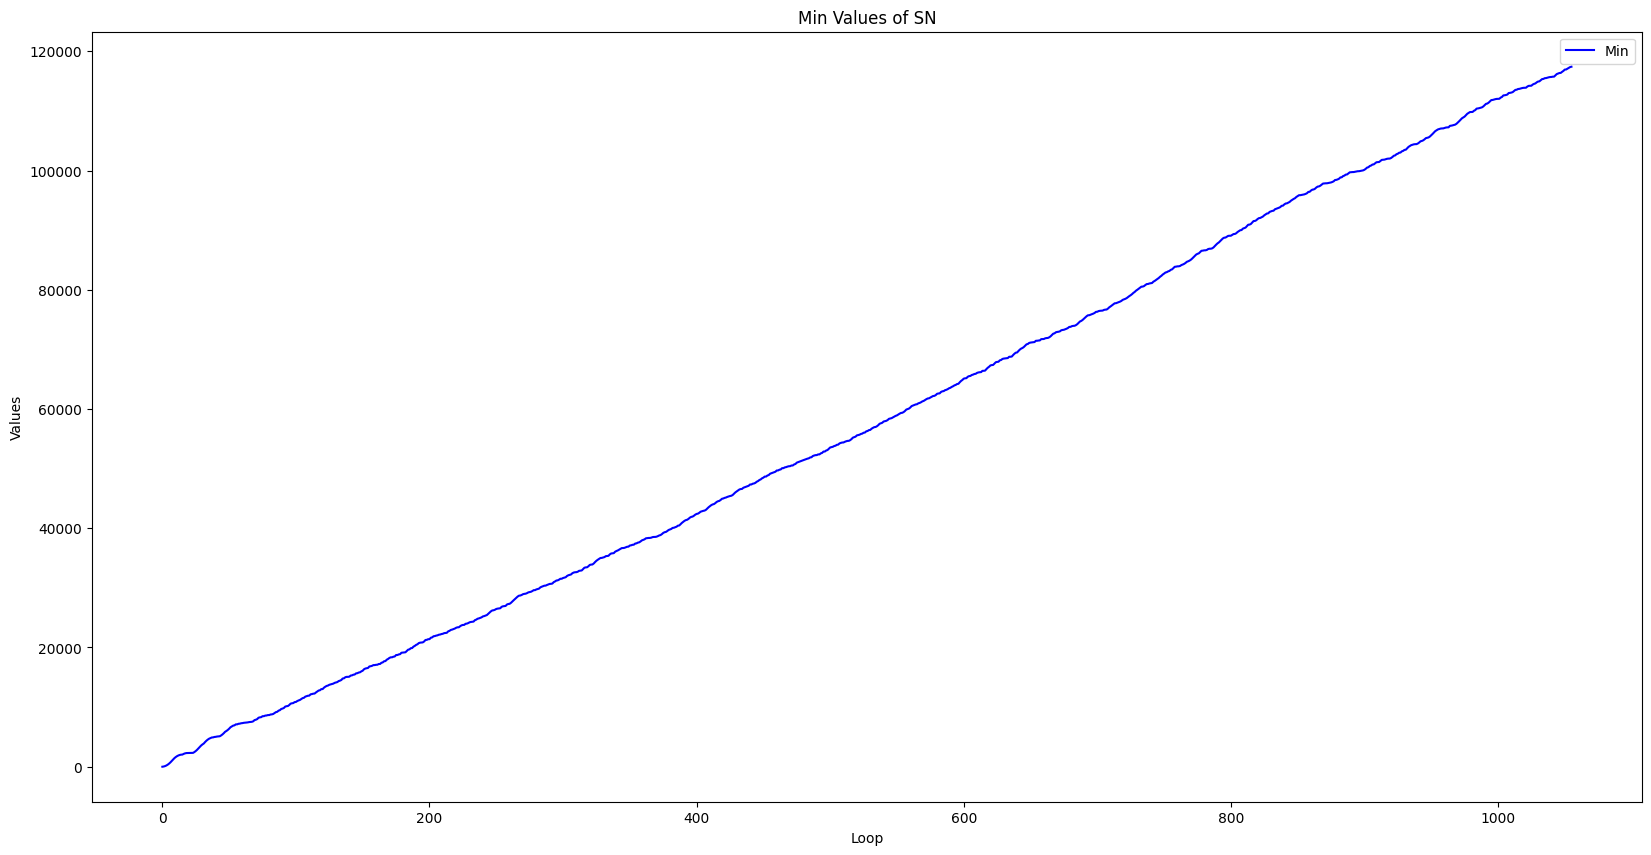

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
plt.plot(_min, label='Min', color='blue')
plt.legend()
plt.title('Min Values of SN')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

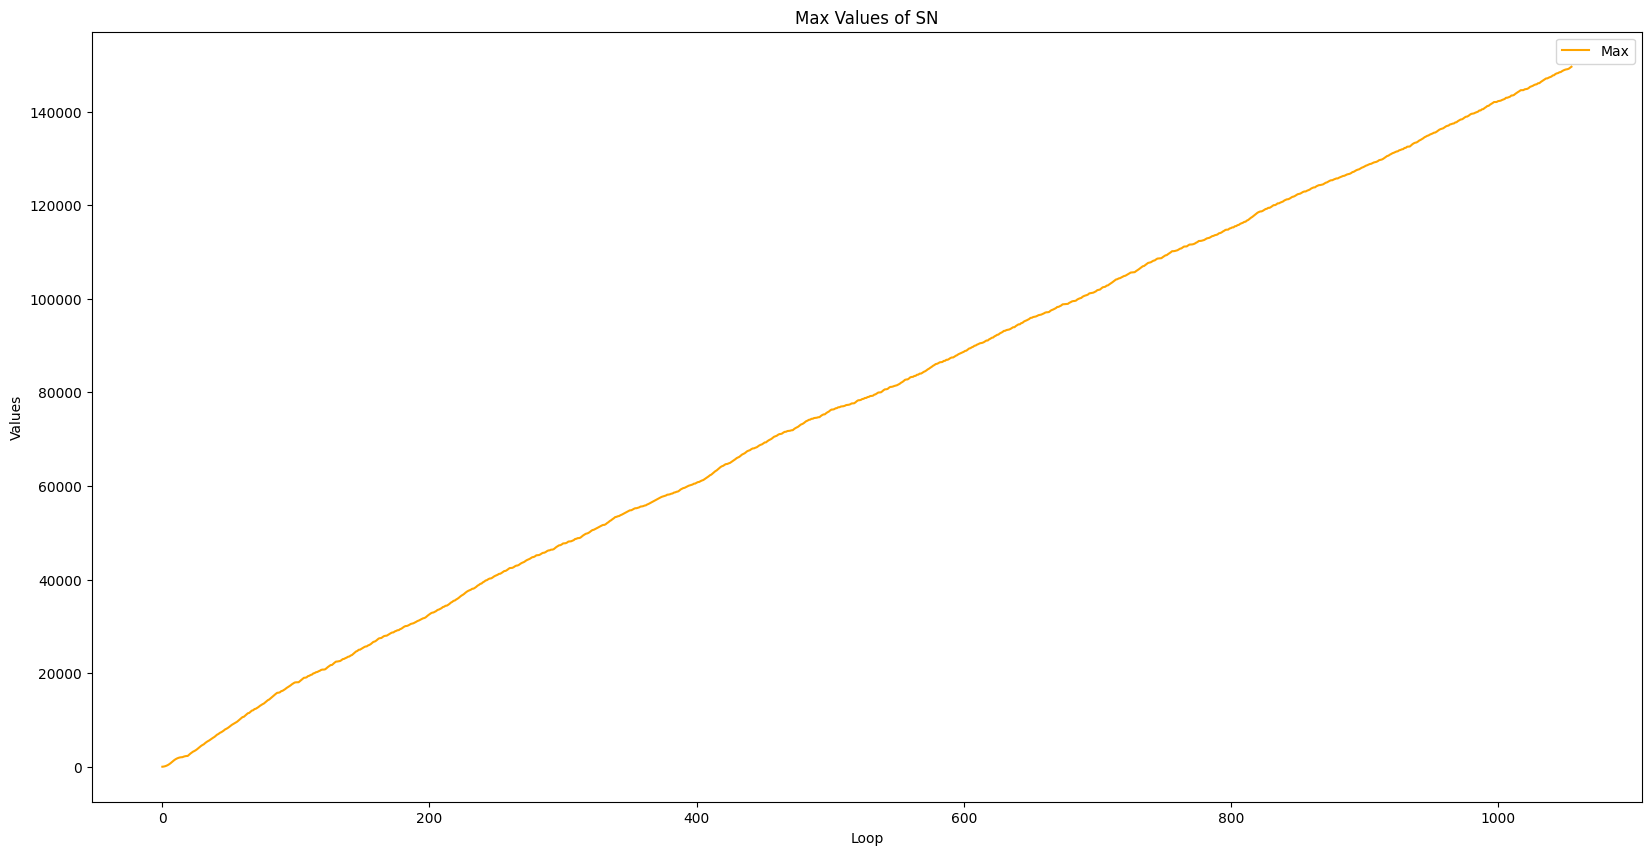

In [14]:
plt.figure(figsize=(20, 10))
plt.plot(_max, label='Max', color='orange')
plt.legend()
plt.title('Max Values of SN')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

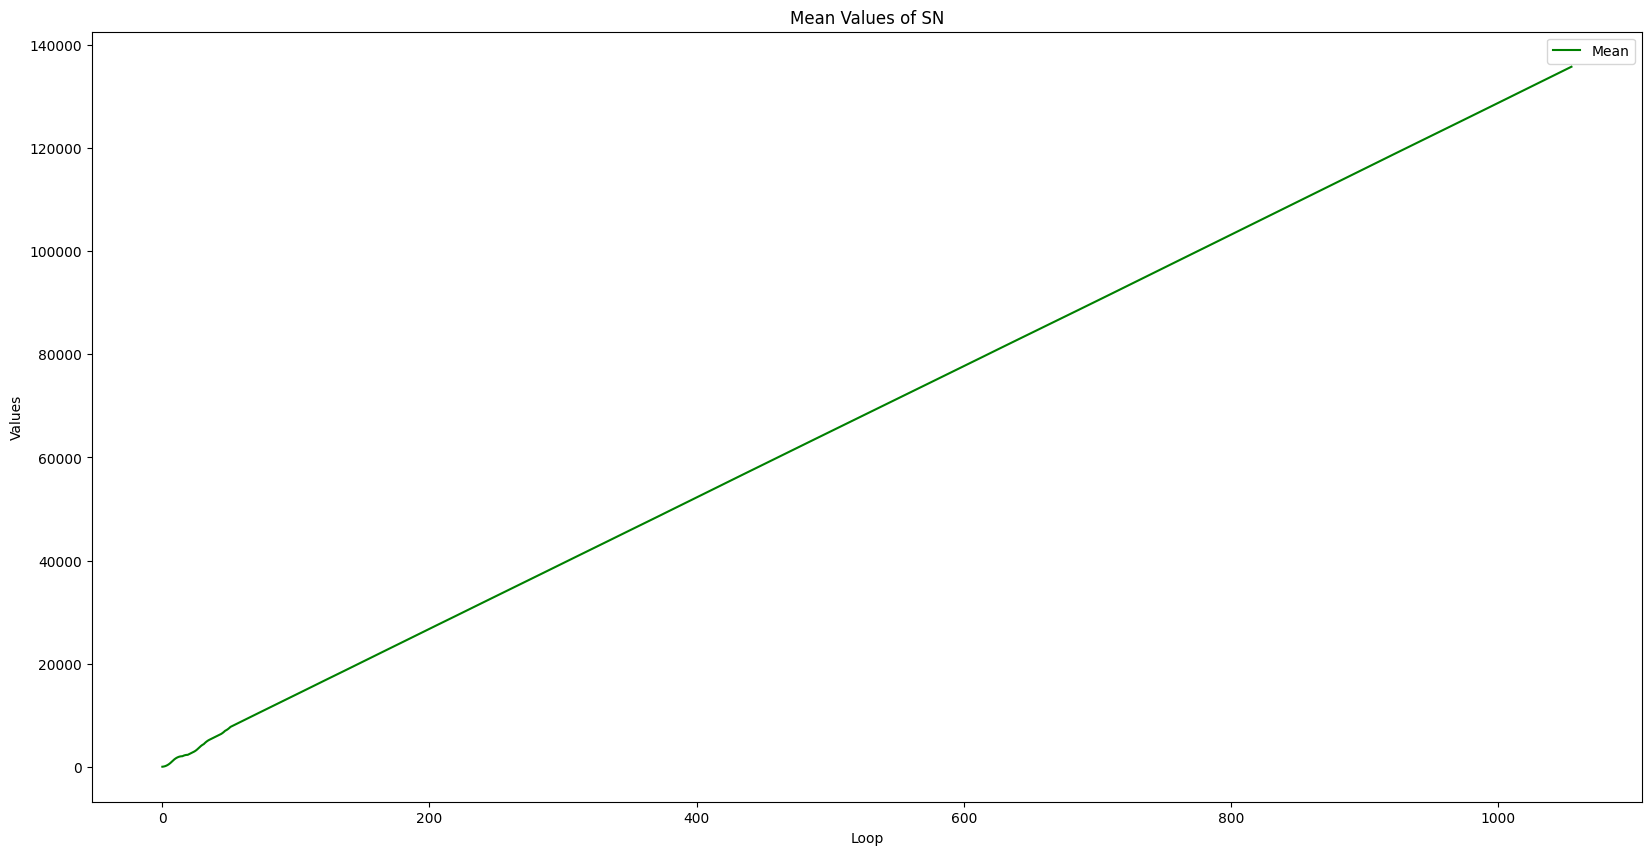

In [15]:
plt.figure(figsize=(20, 10))
plt.plot(mean, label='Mean', color='green')
plt.legend()
plt.title('Mean Values of SN')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

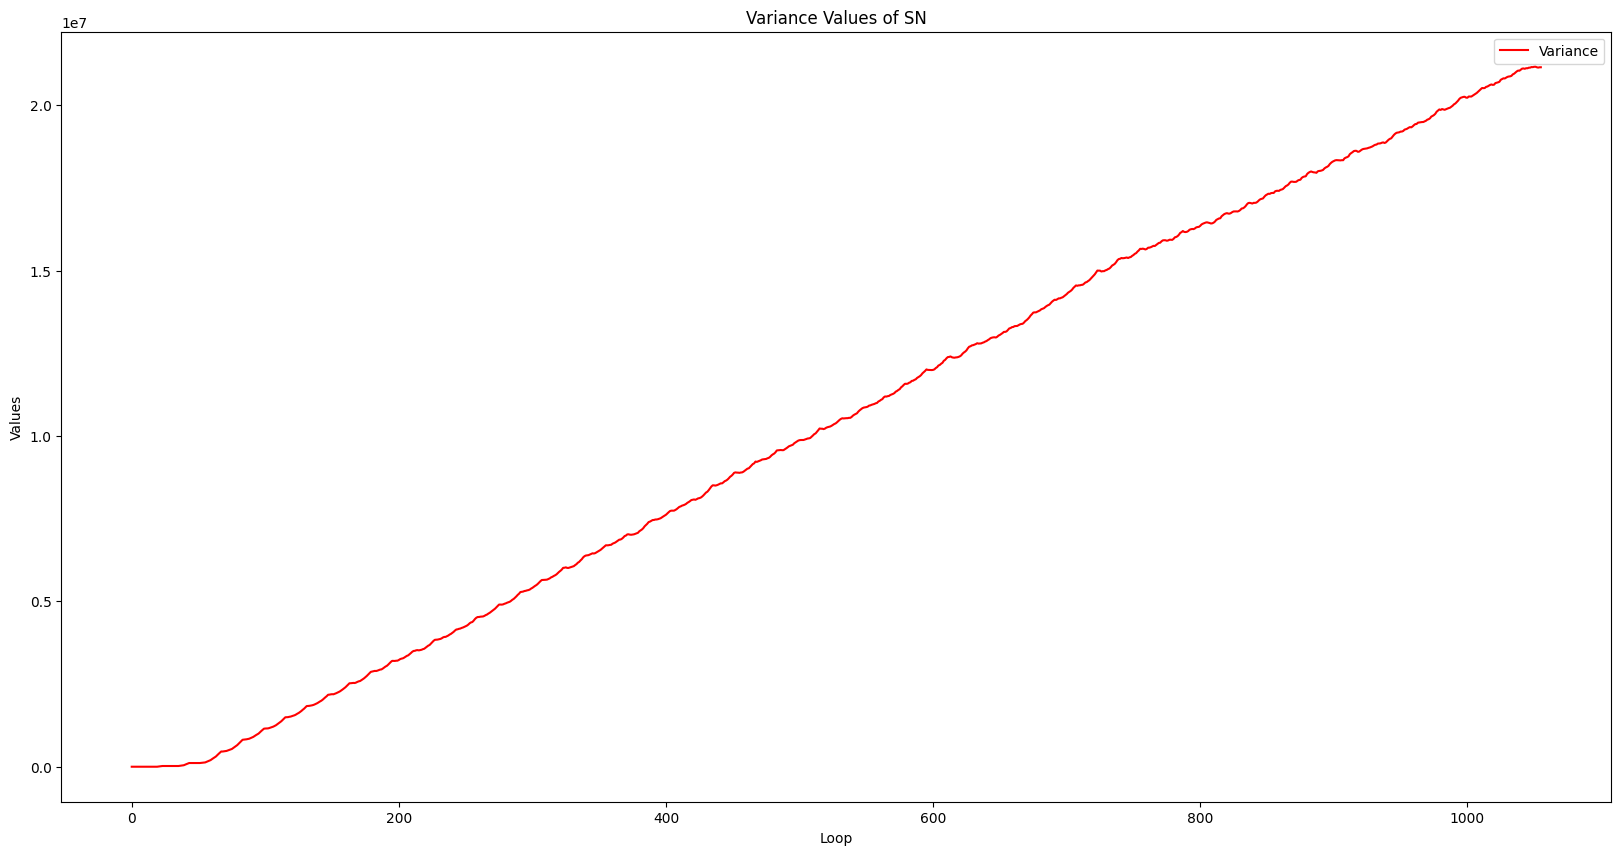

In [16]:
plt.figure(figsize=(20, 10))
plt.plot(var, label='Variance', color='red')
plt.legend()
plt.title('Variance Values of SN')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

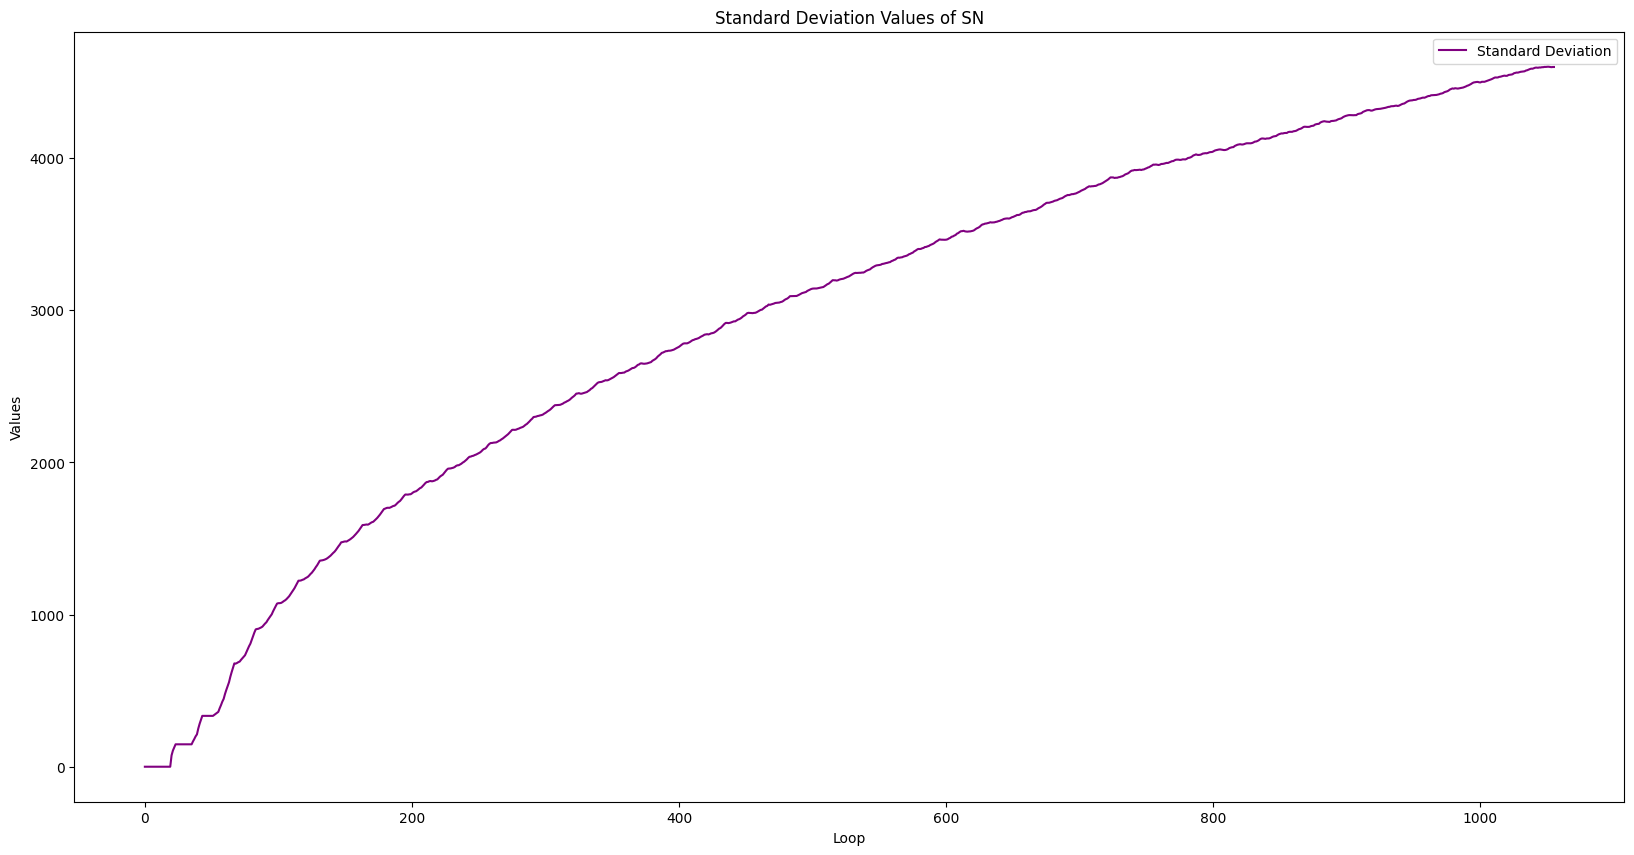

In [17]:
plt.figure(figsize=(20, 10))
plt.plot(std, label='Standard Deviation', color='purple')
plt.legend()
plt.title('Standard Deviation Values of SN')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

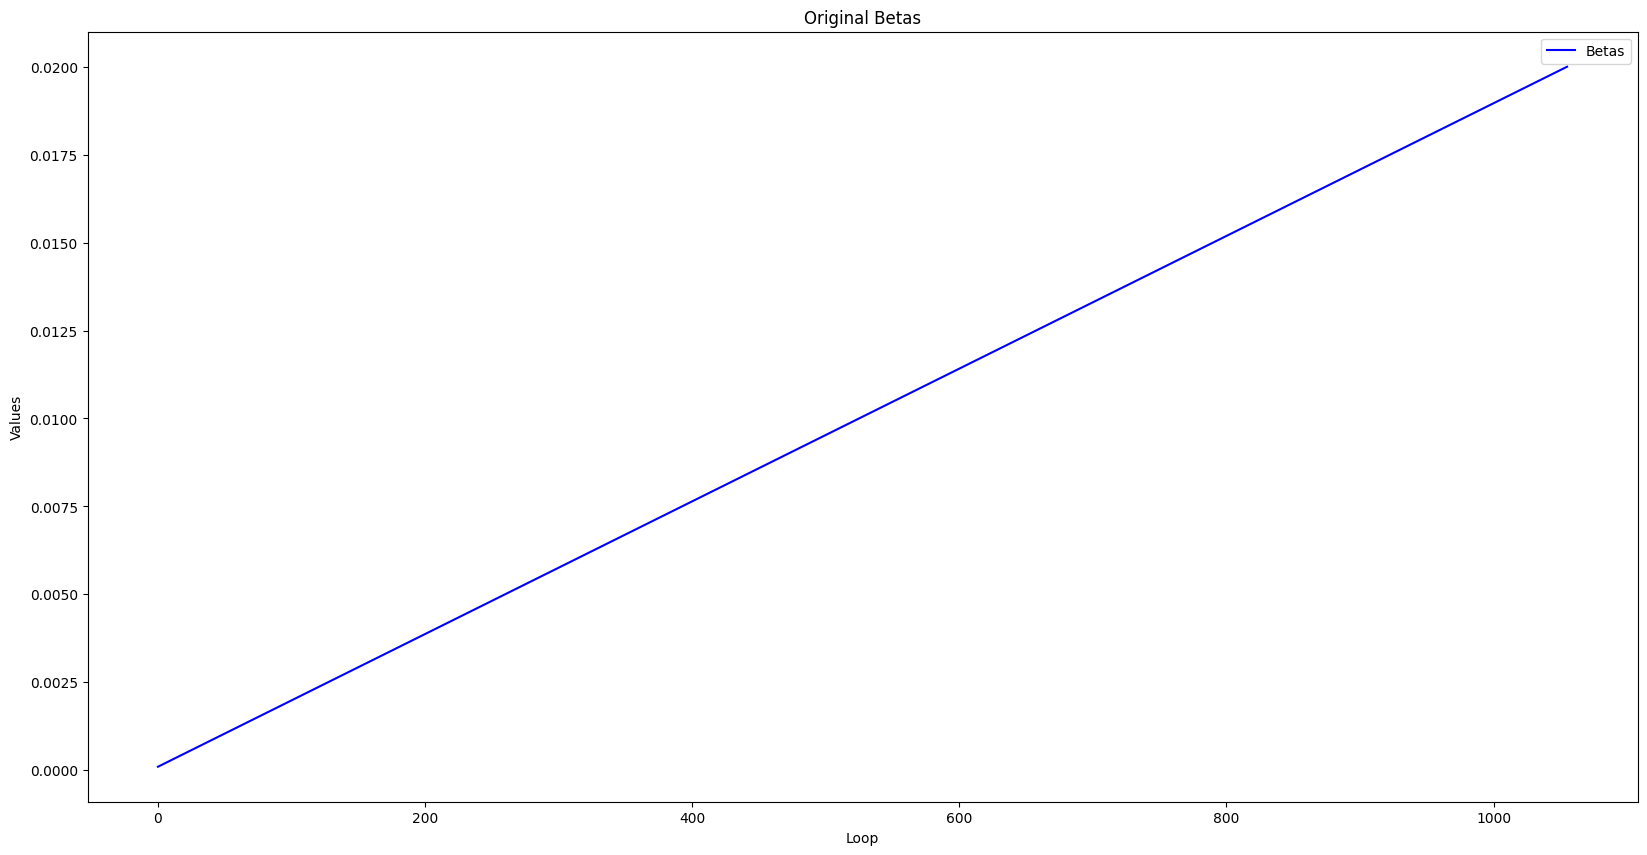

In [18]:
plt.figure(figsize=(20, 10))
plt.plot(betas, label='Betas', color='blue')
plt.legend()
plt.title('Original Betas')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

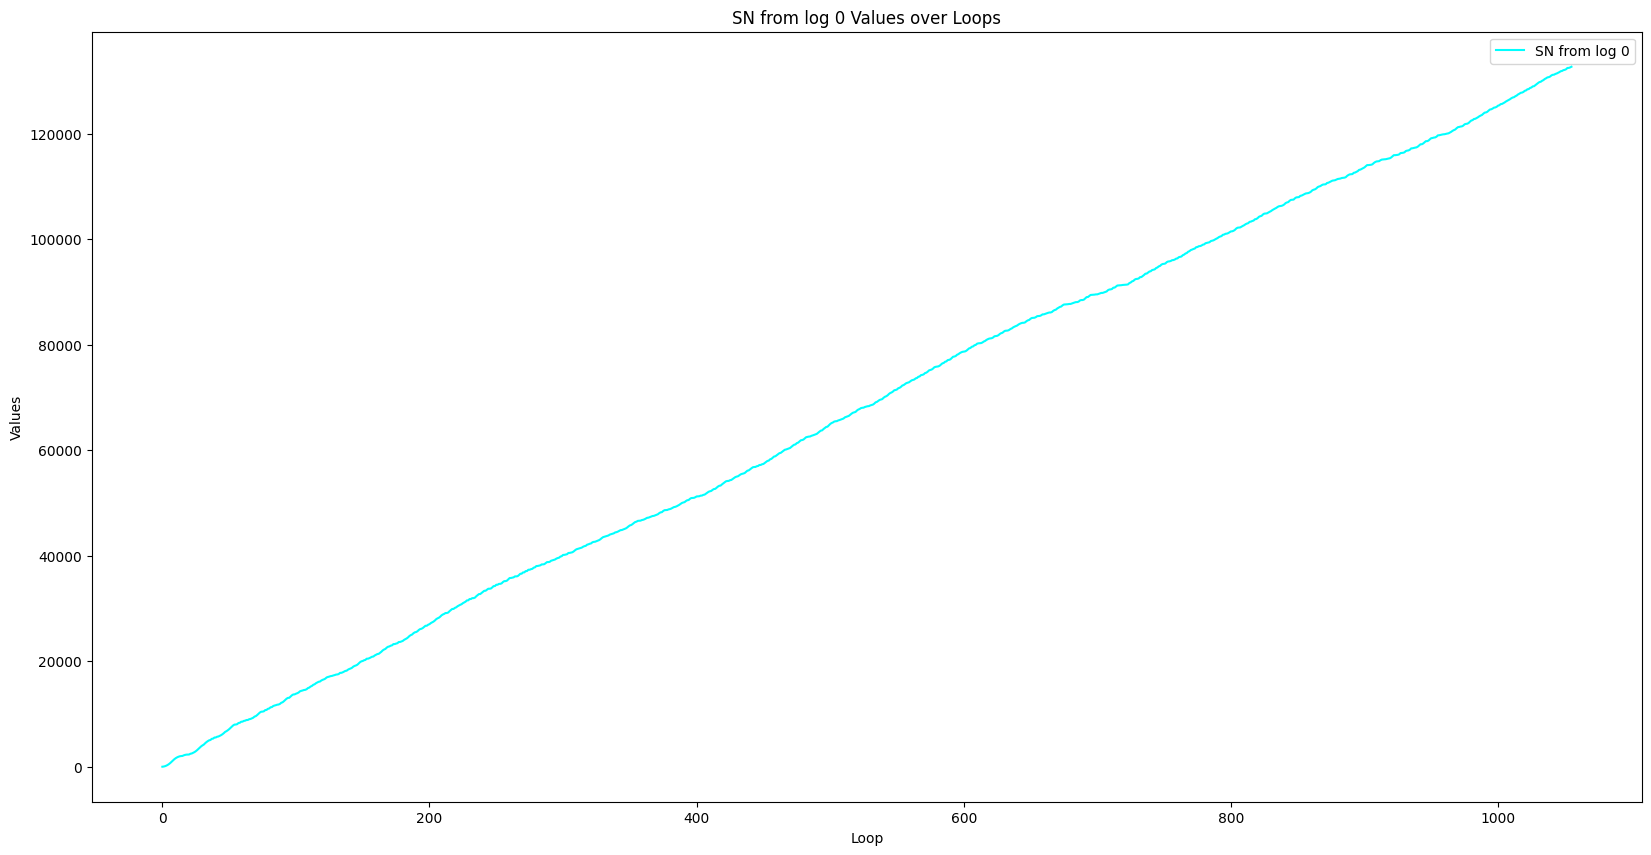

In [19]:
plt.figure(figsize=(20, 10))
plt.plot(sn_array[0], label='SN from log 0', color='cyan')
plt.legend()
plt.title('SN from log 0 Values over Loops')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

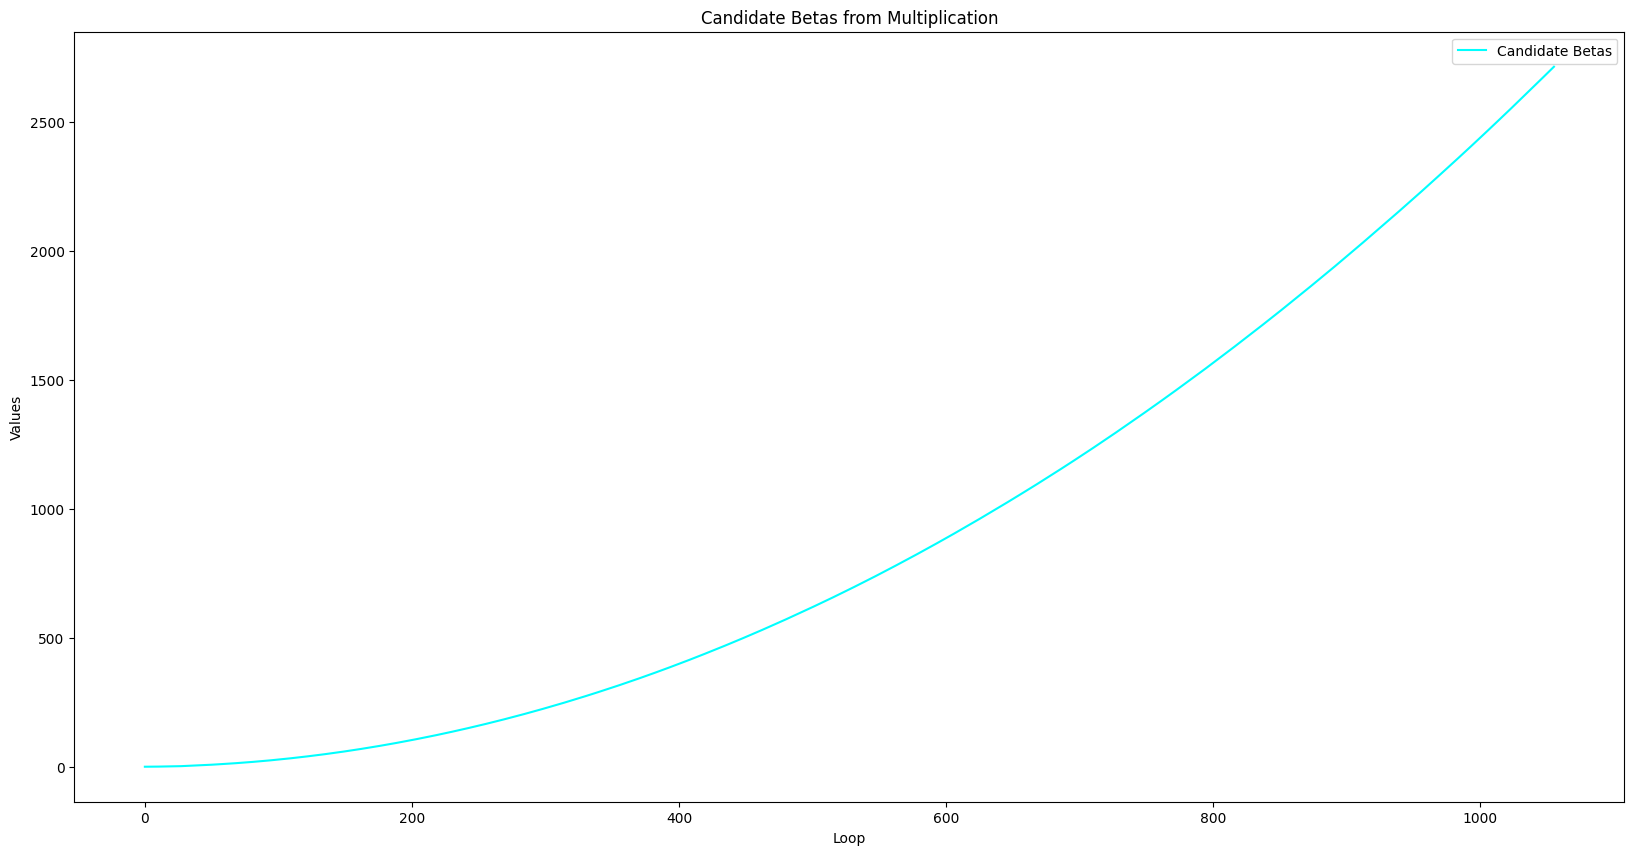

In [20]:
plt.figure(figsize=(20, 10))
plt.plot(beta_candidate_from_multiply, label='Candidate Betas', color='cyan')
plt.legend()
plt.title('Candidate Betas from Multiplication')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

In [21]:
raw_candiate_betas = np.multiply(mean, betas)
raw_min = np.min(raw_candiate_betas, axis=0)
raw_max = np.max(raw_candiate_betas, axis=0)
beta_candidate_rescaled = (raw_candiate_betas - raw_min) / (raw_max - raw_min) * (ori_beta_max - ori_beta_min) + ori_beta_min
beta_candidate_rescaled = np.clip(beta_candidate_rescaled, ori_beta_min, ori_beta_max)
beta_candidate_rescaled = np.array(beta_candidate_rescaled, dtype=np.float64)
print(beta_candidate_rescaled)

[9.99999975e-05 1.00030622e-04 1.00105238e-04 1.00237945e-04 1.00442841e-04 1.00734027e-04 1.01125600e-04 1.01631661e-04 1.02231375e-04 1.02834095e-04 1.03425722e-04 1.03992157e-04 1.04519300e-04 1.04993053e-04 1.05399315e-04 1.05723988e-04 1.06353421e-04 1.06910663e-04 1.07381616e-04 1.07752181e-04 1.08530629e-04 1.09329808e-04 1.10164837e-04 1.11039766e-04 1.11984758e-04 1.13110034e-04 1.14429695e-04 1.15957836e-04 1.17621100e-04 1.19193376e-04 1.20660561e-04 1.22008562e-04 1.23924505e-04 1.25730661e-04 1.27412930e-04 1.28957217e-04 1.30397165e-04 1.31879607e-04 1.33386467e-04 1.34939018e-04 1.36550275e-04 1.38170410e-04 1.39826919e-04 1.41526662e-04 1.43320047e-04 1.45387719e-04 1.47743761e-04 1.50402283e-04 1.52375367e-04 1.54641535e-04 1.57214874e-04 1.60109489e-04 1.62200801e-04 1.64318538e-04 1.66452585e-04 1.68658348e-04 1.70867707e-04 1.73123132e-04 1.75397946e-04 1.77723379e-04 1.80117848e-04 1.82509348e-04 1.84937755e-04 1.87412729e-04 1.89950902e-04 1.92483735e-04 1.9505357

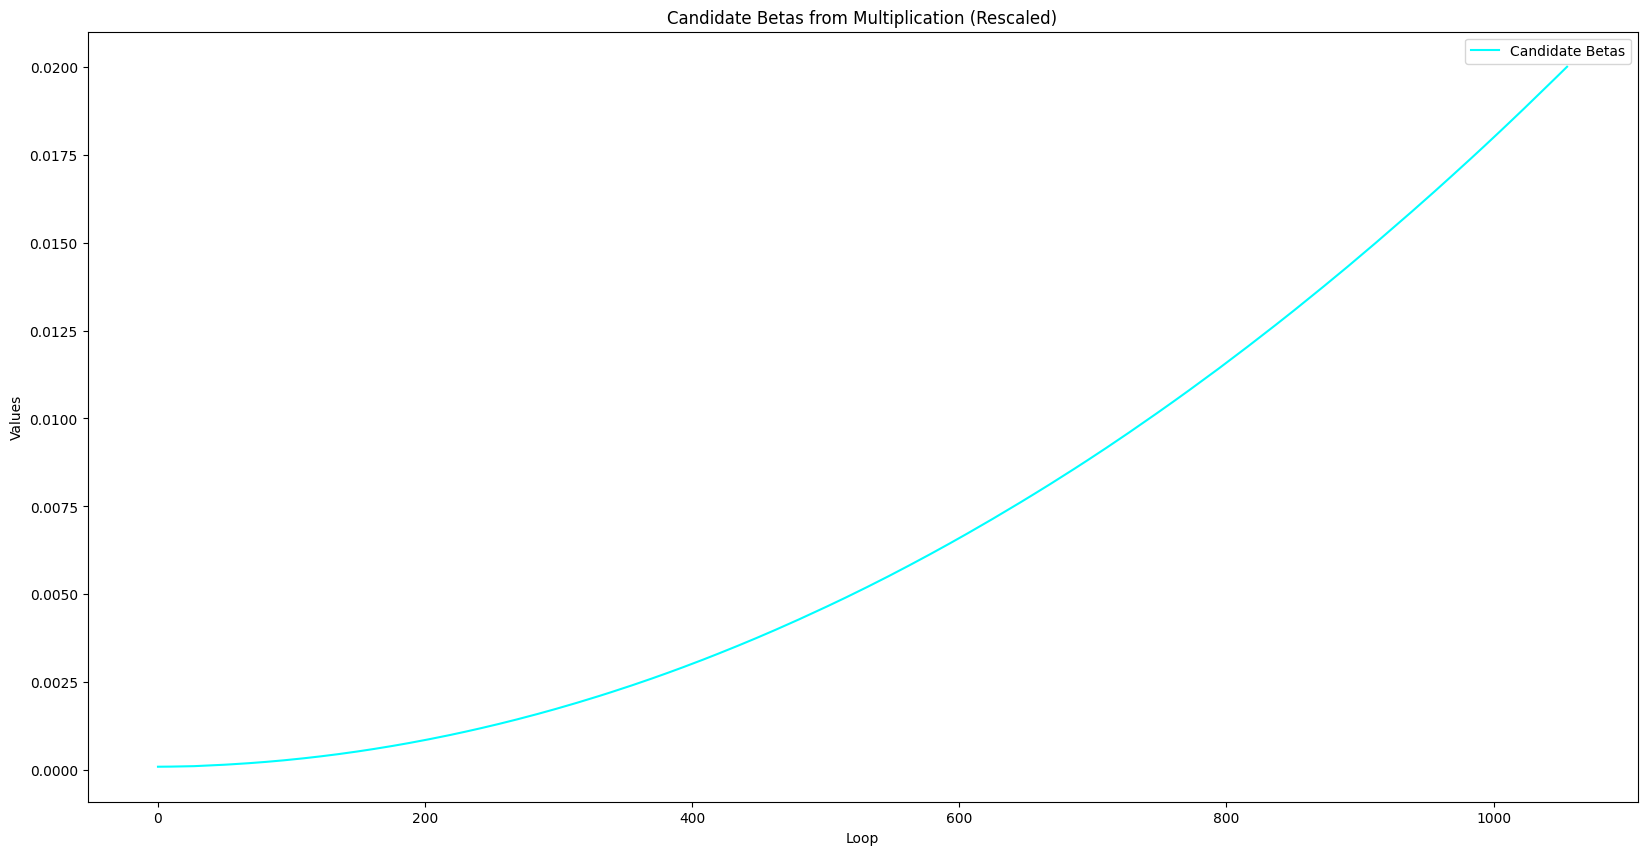

In [22]:
plt.figure(figsize=(20, 10))
plt.plot(beta_candidate_rescaled, label='Candidate Betas', color='cyan')
plt.legend()
plt.title('Candidate Betas from Multiplication (Rescaled)')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

# Beta Scheduling
## Approach 2
**method**  
1. Cumulative all bytes from Hash algorithm calculation logs  
2. Make new Beta scheduling with the cumulative sum of log bytes from intermediate computations on the x-axis  


In [23]:
print(f"Original Beta Min: {ori_beta_min}")
print(f"Original Beta Max: {ori_beta_max}")
print(f"SN Min: {sn_min}")
print(f"SN Max: {sn_max}")
linear_eq_slope = (ori_beta_max - ori_beta_min) / (sn_max - sn_min)
print(f"Linear Equation Slope: {linear_eq_slope}")

Original Beta Min: 9.999999747378752e-05
Original Beta Max: 0.019999999552965164
SN Min: 1.0
SN Max: 135777.4375
Linear Equation Slope: 1.4656445493711953e-07


In [24]:
linear_equation = lambda x: linear_eq_slope * (x - sn_min) + ori_beta_min
beta_candidate_from_linear_eq = linear_equation(mean)
beta_candidate_from_linear_eq = np.array(beta_candidate_from_linear_eq, dtype=np.float64)
print(beta_candidate_from_linear_eq)

[9.99999975e-05 1.05129753e-04 1.15242701e-04 1.30338840e-04 1.50418170e-04 1.75480692e-04 2.05526405e-04 2.40555310e-04 2.77782681e-04 3.10026861e-04 3.37287850e-04 3.59565647e-04 3.76860253e-04 3.89171667e-04 3.96499890e-04 3.98844921e-04 4.16139527e-04 4.28450941e-04 4.35779164e-04 4.38124195e-04 4.57376975e-04 4.76001507e-04 4.94654032e-04 5.13483168e-04 5.33562498e-04 5.58625020e-04 5.88670733e-04 6.23699638e-04 6.60927009e-04 6.93171189e-04 7.20432178e-04 7.42709975e-04 7.79937347e-04 8.12181527e-04 8.39442515e-04 8.61720312e-04 8.80240783e-04 8.98950835e-04 9.17394506e-04 9.36099208e-04 9.55351989e-04 9.73976520e-04 9.92629045e-04 1.01145818e-03 1.03153751e-03 1.05660003e-03 1.08664575e-03 1.12167465e-03 1.14175398e-03 1.16681650e-03 1.19686222e-03 1.23189112e-03 1.25083304e-03 1.26960575e-03 1.28803696e-03 1.30711789e-03 1.32563836e-03 1.34434842e-03 1.36279209e-03 1.38149679e-03 1.40074957e-03 1.41937410e-03 1.43802663e-03 1.45685576e-03 1.47610854e-03 1.49473307e-03 1.5133856

In [25]:
for i in range(len(beta_candidate_from_linear_eq)):
    print(betas[i] - beta_candidate_from_linear_eq[i])

0.0
1.3732800394090642e-05
2.2482416596276823e-05
2.624883405464334e-05
2.5032060045147782e-05
1.883210911970539e-05
7.648937622570478e-06
-8.517396238596039e-06
-2.688222602764982e-05
-4.026383524501103e-05
-4.8662252994510205e-05
-5.20775083799778e-05
-5.0509572297583306e-05
-4.395838653966581e-05
-3.242406752154719e-05
-1.5906557035566538e-05
-1.4338591849341587e-05
-7.787464299085058e-06
3.7468838228640173e-06
2.0264423412675182e-05
1.987421419871277e-05
2.0112224417007845e-05
2.032224082440981e-05
2.035570527127357e-05
1.913891670986289e-05
1.2938936680589961e-05
1.7558233911160173e-06
-1.4410597781541897e-05
-3.277536936293474e-05
-4.6156949476465546e-05
-5.4555454537456036e-05
-5.7970651715262664e-05
-7.633548150431653e-05
-8.971711982550814e-05
-9.811556667883782e-05
-0.00010153070564898354
-0.0001011886346676831
-0.00010103620301650474
-0.00010061727405315636
-0.00010045949279937282
-0.00010084961470184387
-0.00010061154627588804
-0.00010040158807614677
-0.00010036812362928301

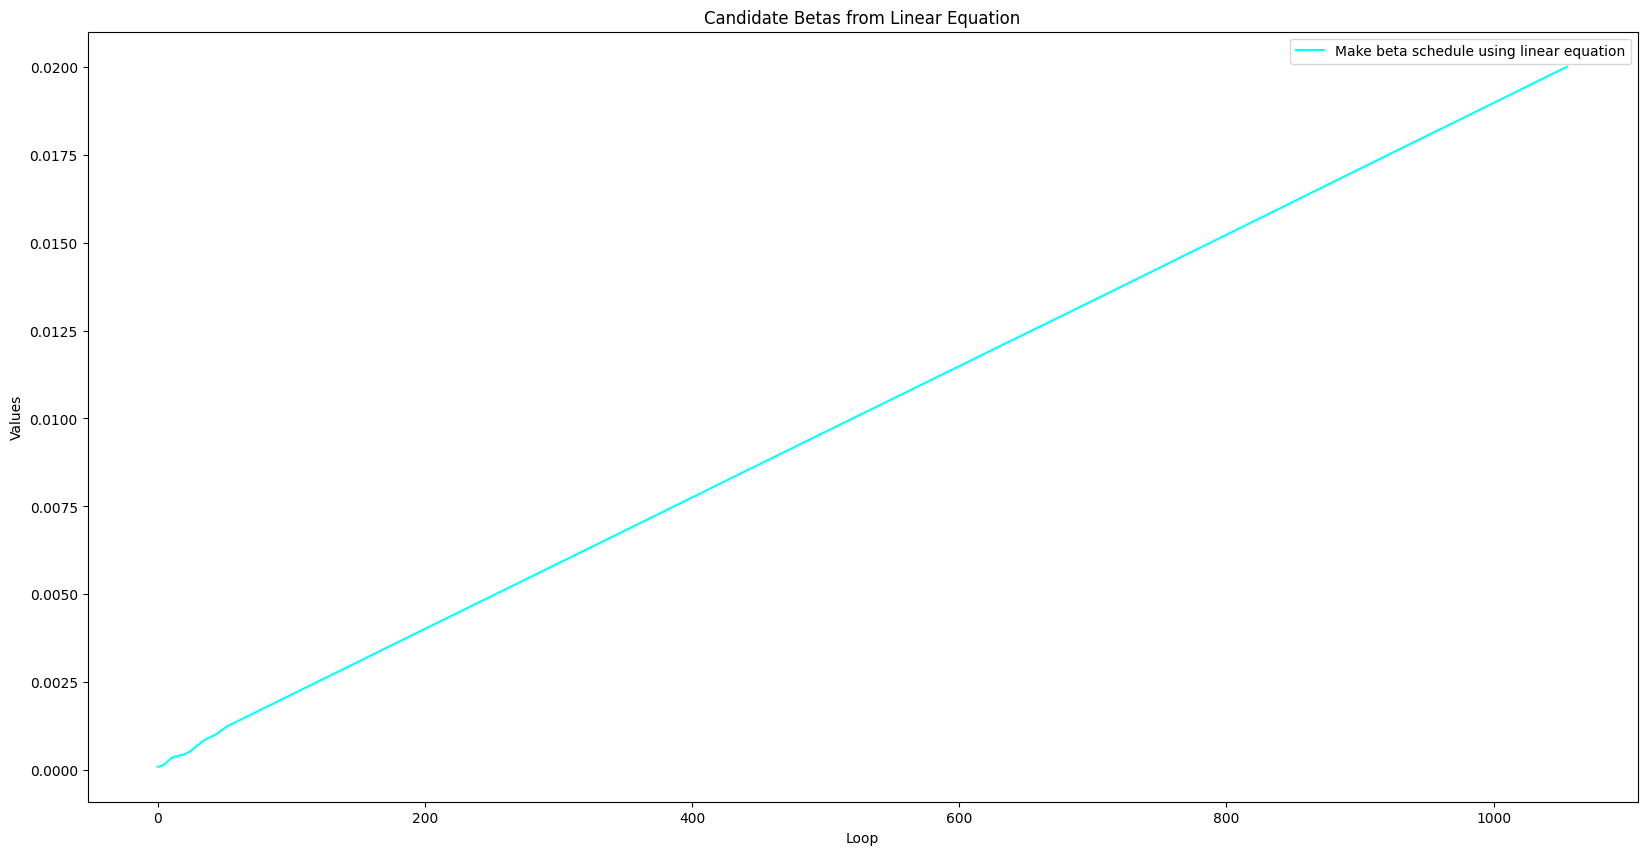

In [26]:
plt.figure(figsize=(20, 10))
plt.plot(beta_candidate_from_linear_eq, label='Make beta schedule using linear equation', color='cyan')
plt.legend()
plt.title('Candidate Betas from Linear Equation')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()